# 10 -- Thermodynamics Source Comparison

This notebook compares the **KBase baseline** (the on-disk bounds
shipped inside each KBase model JSON) against three MSDB per-source
variants on the 100-model representative panel:

1. **Group contribution**
2. **eQuilibrator**
3. **dGPredictor**

### Where the per-source operators come from

[ModelSEEDDatabase PR #263](https://github.com/ModelSEED/ModelSEEDDatabase/pull/263)
restructured each reaction's ``thermodynamics`` dict so that every
source label maps to a ``[dg, dge, operator]`` triple.  We extract the
operator (``>`` / ``<`` / ``=`` / ``?``) for every reaction, per source,
using ``direction_pipeline.snapshot_msdb_per_source`` -- it reads the
JSON shards with ``git show <branch>:Biochemistry/reaction_NN.json`` so
the MSDB working tree is never touched.

The resulting ``{rxn_id: operator}`` maps are persisted under
``results/thermo_sources/`` as both CSV (with ``dg`` / ``dge`` for
context) and JSON (for fast reload), then fed into
``direction_pipeline.panel_growth_with_source`` to re-run FBA on the
panel.

### Self-contained

This notebook produces every CSV and PNG end-to-end -- there is no
external "visualization phase" anymore.  The thin CLI scripts
``scripts/build_thermo_source_network_tables.py`` and
``scripts/build_thermo_source_figures.py`` import the same helpers this
notebook uses (``direction_pipeline.*`` and ``thermo_source_figures.*``),
so any logic change made in either place lands here on the next run.

### Constraint -- MSDB is read-only

This pipeline **never writes anything under**
``/scratch/ctaylor/ModelSEEDDatabase``.  All durable outputs land in
``/scratch/ctaylor/core_models_analysis/results/thermo_sources/`` and
``/scratch/ctaylor/core_models_analysis/reports/figures/thermo_sources/``;
all memoised intermediates live in the per-notebook ``.kbcache/``.

In [1]:
from pathlib import Path
import sys, json, time, csv
from collections import Counter

import pandas as pd

PROJECT_ROOT = Path('/scratch/ctaylor/core_models_analysis')
RESULTS      = PROJECT_ROOT / 'results'
SCRIPTS      = PROJECT_ROOT / 'scripts'
REPORTS      = PROJECT_ROOT / 'reports'

# Make project helpers importable.
sys.path.insert(0, str(SCRIPTS))

# KBUtils NotebookSession -- caches heavy intermediates next to the .ipynb.
from kbutillib.notebook import NotebookSession
session = NotebookSession.for_notebook(
    notebook_file=__file__ if '__file__' in dir() else None,
    project_name='core_models_analysis',
)
print('Cache directory:', session.kbcache_dir)
print('Notebook name :', session.notebook_name)

import direction_pipeline as dp
import growth_heuristics as gh
import thermo_source_figures as tsf
import run_thermo_source_variants as rtv  # shared VARIANT_ORDER / column lists

Cache directory: /scratch/ctaylor/core_models_analysis/notebooks/.kbcache
Notebook name : None


In [2]:
# === Parameters =====================================================
# Edit these to point at a different panel / branch / source set.  All
# writable paths live under PROJECT_ROOT / 'results' or PROJECT_ROOT /
# 'reports'.
#
# IMPORTANT: /scratch/ctaylor/ModelSEEDDatabase is treated as READ-ONLY.
# This notebook never writes there -- per-source snapshots are taken
# via `git show <branch>:Biochemistry/reaction_NN.json` so the MSDB
# working tree is never mutated.

PANEL_IDS_PATH = Path('/scratch/ctaylor/core_models_analysis/results/selected_ids.txt')

# MSDB branch that contains PR #263's per-source thermodynamics dicts.
MSDB_BRANCH    = 'origin/dev'

# (label, slug) pairs.  Labels match the keys inside each reaction's
# ``thermodynamics`` dict; slugs are used for output filenames.
SOURCES = [
    ('Group contribution', 'gc'),
    ('eQuilibrator',       'eq'),
    ('dGPredictor',        'dgp'),
]

# All per-source artifacts (snapshots, coverage, override tables) land here.
OUTPUT_DIR = Path('/scratch/ctaylor/core_models_analysis/results/thermo_sources/')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Figures land here.
FIGURES_DIR = Path('/scratch/ctaylor/core_models_analysis/reports/figures/thermo_sources/')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# MSDB-dev reversibility snapshot used to classify the "before" bound
# class in the override-transition tables.  Produced read-only via
# dp.snapshot_msdb (git show, no working-tree writes).
MSDB_SNAPSHOT_PATH = Path('/scratch/ctaylor/core_models_analysis/results/rxn_directions_msdb_dev.csv')

# FBA worker count -- keep modest; the pool spawns one process per worker.
N_WORKERS = 4

# Load the panel ids.
PANEL_IDS = PANEL_IDS_PATH.read_text().split()
print(f'Panel: {len(PANEL_IDS)} models from {PANEL_IDS_PATH}')

# Registry the cross-variant summary cell reads from.
runs = {}

Panel: 100 models from /scratch/ctaylor/core_models_analysis/results/selected_ids.txt


In [3]:
# === Snapshot per-source operators from MSDB (idempotent, read-only) ==
# For each (label, slug) we call dp.snapshot_msdb_per_source(...) which
# reads Biochemistry/reaction_NN.json from MSDB_BRANCH via `git show`
# (the MSDB working tree is never touched) and writes:
#
#   OUTPUT_DIR / rxn_directions_{slug}.csv  -- rxn_id, operator, dg, dge
#   OUTPUT_DIR / rxn_directions_{slug}.json -- {rxn_id: operator}
#
# Idempotent: if the CSV already exists we just reload it from JSON
# instead of re-running the snapshot.

operator_maps = {}
for label, slug in SOURCES:
    out_csv  = OUTPUT_DIR / f'rxn_directions_{slug}.csv'
    out_json = OUTPUT_DIR / f'rxn_directions_{slug}.json'
    if out_csv.exists() and out_json.exists():
        op_map = json.loads(out_json.read_text())
        print(f'  exists  -> {out_csv.name}  ({len(op_map)} reactions)')
    else:
        t = time.time()
        op_map = dp.snapshot_msdb_per_source(
            branch=MSDB_BRANCH,
            source=label,
            out_csv=out_csv,
            out_json=out_json,
        )
        print(f'  wrote   -> {out_csv.name}  ({len(op_map)} reactions in {time.time()-t:.1f}s)')

    counts = Counter(op_map.values())
    op_summary = ', '.join(f"{k!r}={counts[k]}" for k in sorted(counts))
    print(f'    {label:<22s} coverage: {len(op_map):>6d} rxns  [{op_summary}]')
    operator_maps[slug] = op_map

  exists  -> rxn_directions_gc.csv  (25812 reactions)
    Group contribution     coverage:  25812 rxns  ['<'=1692, '='=14272, '>'=9848]
  exists  -> rxn_directions_eq.csv  (19498 reactions)
    eQuilibrator           coverage:  19498 rxns  ['<'=1378, '='=10415, '>'=7705]
  exists  -> rxn_directions_dgp.csv  (27715 reactions)
    dGPredictor            coverage:  27715 rxns  ['<'=3028, '='=12425, '>'=12262]


In [4]:
# === KBase baseline panel FBA ========================================
# reversibility_map=None tells growth_heuristics to KEEP the on-disk
# bounds shipped in each KBase model JSON -- this is the "what KBase
# gives you out of the box" comparison point.

CACHE_KEY_BASELINE = 'thermo_sources_fba_kbase_baseline_v1'
try:
    baseline_results = session.cache.load(CACHE_KEY_BASELINE)
    print(f'  cached  -> kbase_baseline ({len(baseline_results)} models)')
except KeyError:
    t = time.time()
    baseline_results = gh.run_panel(
        PANEL_IDS,
        reversibility_map=None,
        baseline_map=None,
        n_workers=N_WORKERS,
    )
    session.cache.save(CACHE_KEY_BASELINE, baseline_results, type_hint='dict',
                       metadata={'panel': str(PANEL_IDS_PATH),
                                 'variant': 'kbase_baseline'})
    print(f'  wrote   -> kbase_baseline panel FBA in {time.time()-t:.1f}s')

n_grow = sum(1 for r in baseline_results if r.get('grows'))
print(f'  kbase_baseline: {n_grow}/{len(baseline_results)} models grow')

runs['kbase_baseline'] = {
    'label': 'KBase baseline (on-disk bounds)',
    'results': baseline_results,
}

  cached  -> kbase_baseline (100 models)
  kbase_baseline: 100/100 models grow


In [5]:
# === Group contribution variant ==
# Reads OUTPUT_DIR / rxn_directions_gc.csv and reruns panel FBA via
# dp.panel_growth_with_source(...).  Reactions absent from the per-source
# map keep their on-disk KBase bounds (override_bounds skips ids that
# aren't in the supplied map).

CACHE_KEY_GC = 'thermo_sources_fba_gc_v1'
SOURCE_CSV_GC = OUTPUT_DIR / 'rxn_directions_gc.csv'

try:
    variant_results_gc = session.cache.load(CACHE_KEY_GC)
    print(f'  cached  -> gc ({len(variant_results_gc)} models)')
except KeyError:
    t = time.time()
    variant_results_gc = dp.panel_growth_with_source(
        PANEL_IDS,
        SOURCE_CSV_GC,
        baseline_map=None,
        n_workers=N_WORKERS,
    )
    session.cache.save(CACHE_KEY_GC, variant_results_gc,
                       type_hint='dict',
                       metadata={'panel': str(PANEL_IDS_PATH),
                                 'variant': 'gc',
                                 'source_csv': str(SOURCE_CSV_GC)})
    print(f'  wrote   -> gc panel FBA in {time.time()-t:.1f}s')

n_grow_gc = sum(1 for r in variant_results_gc if r.get('grows'))
print(f'  gc: {n_grow_gc}/{len(variant_results_gc)} models grow')

runs['gc'] = {
    'label': 'Group contribution',
    'results': variant_results_gc,
}

  cached  -> gc (100 models)
  gc: 100/100 models grow


In [6]:
# === eQuilibrator variant ==
# Reads OUTPUT_DIR / rxn_directions_eq.csv and reruns panel FBA via
# dp.panel_growth_with_source(...).  Reactions absent from the per-source
# map keep their on-disk KBase bounds (override_bounds skips ids that
# aren't in the supplied map).

CACHE_KEY_EQ = 'thermo_sources_fba_eq_v1'
SOURCE_CSV_EQ = OUTPUT_DIR / 'rxn_directions_eq.csv'

try:
    variant_results_eq = session.cache.load(CACHE_KEY_EQ)
    print(f'  cached  -> eq ({len(variant_results_eq)} models)')
except KeyError:
    t = time.time()
    variant_results_eq = dp.panel_growth_with_source(
        PANEL_IDS,
        SOURCE_CSV_EQ,
        baseline_map=None,
        n_workers=N_WORKERS,
    )
    session.cache.save(CACHE_KEY_EQ, variant_results_eq,
                       type_hint='dict',
                       metadata={'panel': str(PANEL_IDS_PATH),
                                 'variant': 'eq',
                                 'source_csv': str(SOURCE_CSV_EQ)})
    print(f'  wrote   -> eq panel FBA in {time.time()-t:.1f}s')

n_grow_eq = sum(1 for r in variant_results_eq if r.get('grows'))
print(f'  eq: {n_grow_eq}/{len(variant_results_eq)} models grow')

runs['eq'] = {
    'label': 'eQuilibrator',
    'results': variant_results_eq,
}

  cached  -> eq (100 models)
  eq: 100/100 models grow


In [7]:
# === dGPredictor variant ==
# Reads OUTPUT_DIR / rxn_directions_dgp.csv and reruns panel FBA via
# dp.panel_growth_with_source(...).  Reactions absent from the per-source
# map keep their on-disk KBase bounds (override_bounds skips ids that
# aren't in the supplied map).

CACHE_KEY_DGP = 'thermo_sources_fba_dgp_v1'
SOURCE_CSV_DGP = OUTPUT_DIR / 'rxn_directions_dgp.csv'

try:
    variant_results_dgp = session.cache.load(CACHE_KEY_DGP)
    print(f'  cached  -> dgp ({len(variant_results_dgp)} models)')
except KeyError:
    t = time.time()
    variant_results_dgp = dp.panel_growth_with_source(
        PANEL_IDS,
        SOURCE_CSV_DGP,
        baseline_map=None,
        n_workers=N_WORKERS,
    )
    session.cache.save(CACHE_KEY_DGP, variant_results_dgp,
                       type_hint='dict',
                       metadata={'panel': str(PANEL_IDS_PATH),
                                 'variant': 'dgp',
                                 'source_csv': str(SOURCE_CSV_DGP)})
    print(f'  wrote   -> dgp panel FBA in {time.time()-t:.1f}s')

n_grow_dgp = sum(1 for r in variant_results_dgp if r.get('grows'))
print(f'  dgp: {n_grow_dgp}/{len(variant_results_dgp)} models grow')

runs['dgp'] = {
    'label': 'dGPredictor',
    'results': variant_results_dgp,
}

  cached  -> dgp (100 models)
  dgp: 94/100 models grow


In [8]:
# === Cross-variant summary ==========================================
# Builds:
#
#   panel_fba_long.csv     -- one row per (variant, model_id):
#       variant, label, model_id, status, growth_flux, grows, n_overrides
#
#   panel_fba_summary.csv  -- one row per variant:
#       variant, label, n_panel, n_growers, frac_growers, mean_flux,
#       median_flux, n_status_optimal, mean_overrides_per_model
#
# Schema, sort order, and writer (pandas .to_csv with LF line endings)
# are shared with scripts/run_thermo_source_variants.py via the
# ``rtv`` module so both producers emit byte-identical files.

long_rows = []
for variant_key, run in runs.items():
    label = rtv.VARIANT_LABELS.get(variant_key, run.get('label', variant_key))
    for r in run['results']:
        long_rows.append({
            'variant'    : variant_key,
            'label'      : label,
            'model_id'   : r.get('model_id', ''),
            'status'     : r.get('status', '') or '',
            'growth_flux': float(r.get('growth_flux', 0.0) or 0.0),
            'grows'      : bool(r.get('grows', False)),
            'n_overrides': int(r.get('n_overrides', 0) or 0),
        })

long_df = pd.DataFrame(long_rows, columns=rtv.LONG_COLS)
# Canonical sort: variant in VARIANT_ORDER, then model_id ascending.
long_df = rtv.sort_long_df(long_df)

long_csv = OUTPUT_DIR / 'panel_fba_long.csv'
long_df.to_csv(long_csv, index=False, lineterminator='\n')
print(f'wrote {long_csv}  ({len(long_df)} rows, {long_df["variant"].nunique()} variants)')

# Per-variant aggregate -- built by the same helper the CLI uses so the
# rows match column-for-column.
summary_df = rtv._build_summary_df(long_df)
summary_csv = OUTPUT_DIR / 'panel_fba_summary.csv'
summary_df.to_csv(summary_csv, index=False, lineterminator='\n')
print(f'wrote {summary_csv}')
print()
print('Per-variant summary:')
print(summary_df.to_string(index=False))

wrote /scratch/ctaylor/core_models_analysis/results/thermo_sources/panel_fba_long.csv  (400 rows, 4 variants)
wrote /scratch/ctaylor/core_models_analysis/results/thermo_sources/panel_fba_summary.csv

Per-variant summary:
       variant                           label  n_panel  n_growers  frac_growers  mean_flux  median_flux  n_status_optimal  mean_overrides_per_model
kbase_baseline KBase baseline (on-disk bounds)      100        100          1.00  38.394149    33.956593               100                      0.00
            gc              Group contribution      100        100          1.00  52.163254    50.925602               100                     89.48
            eq                    eQuilibrator      100        100          1.00  63.770036    62.385554               100                     81.65
           dgp                     dGPredictor      100         94          0.94  46.123391    48.228994               100                     78.06


In [9]:
# === Per-source network tables: coverage + override transitions ======
# Identical schema to what build_thermo_source_network_tables.py would
# emit -- this notebook calls the same direction_pipeline helpers.
#
#   coverage_<slug>.csv  columns:
#       model_id, n_reactions, n_non_exchange, n_with_seed_anno,
#       n_in_msdb, n_covered_by_source, frac_covered, n_uncovered_by_source
#
#   overrides_<slug>.csv columns (wide schema, one row per model):
#       model_id, source, n_overrides_applied,
#       n_fwd_to_rev, n_rev_to_fwd, n_fwd_to_reversible,
#       n_reversible_to_fwd, n_rev_to_reversible, n_reversible_to_rev,
#       n_unchanged, n_other
#
# The "before" bound class is derived from the MSDB-dev reversibility
# snapshot (results/rxn_directions_msdb_dev.csv) -- the same
# classification gh._bounds_for_rev would apply to the on-disk KBase
# bounds.  The "after" bound class is derived from the per-source
# operator.  This matches what fig_override_transitions expects.

# MSDB-dev snapshot is required for the override classification.  If the
# user hasn't produced it yet, snapshot it now (read-only, git show).
if not MSDB_SNAPSHOT_PATH.exists():
    t = time.time()
    dp.snapshot_msdb(branch=MSDB_BRANCH, out_path=MSDB_SNAPSHOT_PATH)
    print(f'wrote MSDB-dev snapshot in {time.time()-t:.1f}s -> {MSDB_SNAPSHOT_PATH}')
else:
    print(f'  exists  -> {MSDB_SNAPSHOT_PATH.name}')

msdb_map = dp.load_msdb_reversibility_map(MSDB_SNAPSHOT_PATH)
print(f'loaded MSDB-dev map: {len(msdb_map)} rxn_ids')

skip_prefixes = ('EX_', 'SK_', 'DM_', 'bio')

def _coverage_rows_for_source(panel_ids, source_csv, msdb_map):
    '''Wide-schema coverage rows: dp.source_coverage + the two legacy columns.'''
    cov = dp.source_coverage(panel_ids, source_csv)
    rows = []
    for mid in panel_ids:
        base = cov[mid]
        n_non_exchange = 0
        n_in_msdb = 0
        model_path = gh.MODELS_DIR / f'{mid}.json'
        if model_path.exists():
            with model_path.open() as fh:
                model = json.load(fh)
            for rxn in model.get('reactions', []):
                rid = rxn.get('id') or ''
                if rid.startswith(skip_prefixes):
                    continue
                n_non_exchange += 1
                anno = rxn.get('annotation') or {}
                seed = anno.get('seed.reaction')
                if isinstance(seed, list):
                    seed = seed[0] if seed else None
                if seed and seed in msdb_map:
                    n_in_msdb += 1
        rows.append({
            'model_id':              mid,
            'n_reactions':           base['n_reactions'],
            'n_non_exchange':        n_non_exchange,
            'n_with_seed_anno':      base['n_with_seed_anno'],
            'n_in_msdb':             n_in_msdb,
            'n_covered_by_source':   base['n_covered_by_source'],
            'frac_covered':          base['frac_covered'],
            'n_uncovered_by_source': base['n_with_seed_anno'] - base['n_covered_by_source'],
        })
    return rows

COVERAGE_COLS = [
    'model_id', 'n_reactions', 'n_non_exchange', 'n_with_seed_anno',
    'n_in_msdb', 'n_covered_by_source', 'frac_covered',
    'n_uncovered_by_source',
]

for label, slug in SOURCES:
    source_csv = OUTPUT_DIR / f'rxn_directions_{slug}.csv'

    cov_rows = _coverage_rows_for_source(PANEL_IDS, source_csv, msdb_map)
    cov_df = pd.DataFrame(cov_rows, columns=COVERAGE_COLS)
    cov_path = OUTPUT_DIR / f'coverage_{slug}.csv'
    cov_df.to_csv(cov_path, index=False, lineterminator='\n')
    mean_frac = float(cov_df['frac_covered'].mean()) if len(cov_df) else 0.0
    print(f'wrote {cov_path}  (mean frac_covered = {mean_frac:.3f})')

    ovr_rows = dp.override_transitions(PANEL_IDS, source_csv, MSDB_SNAPSHOT_PATH, slug)
    ovr_df = pd.DataFrame(ovr_rows, columns=list(dp.OVERRIDE_TRANSITION_COLS))
    ovr_path = OUTPUT_DIR / f'overrides_{slug}.csv'
    ovr_df.to_csv(ovr_path, index=False, lineterminator='\n')
    n_changed = int(
        ovr_df[['n_fwd_to_rev', 'n_rev_to_fwd', 'n_fwd_to_reversible',
                'n_reversible_to_fwd', 'n_rev_to_reversible',
                'n_reversible_to_rev', 'n_other']].sum().sum()
    )
    n_applied = int(ovr_df['n_overrides_applied'].sum())
    print(f'wrote {ovr_path}  ({n_changed}/{n_applied} reaction-instances changed class)')

  exists  -> rxn_directions_msdb_dev.csv
loaded MSDB-dev map: 56012 rxn_ids


wrote /scratch/ctaylor/core_models_analysis/results/thermo_sources/coverage_gc.csv  (mean frac_covered = 0.758)
wrote /scratch/ctaylor/core_models_analysis/results/thermo_sources/overrides_gc.csv  (1859/8948 reaction-instances changed class)


wrote /scratch/ctaylor/core_models_analysis/results/thermo_sources/coverage_eq.csv  (mean frac_covered = 0.693)
wrote /scratch/ctaylor/core_models_analysis/results/thermo_sources/overrides_eq.csv  (0/8165 reaction-instances changed class)


wrote /scratch/ctaylor/core_models_analysis/results/thermo_sources/coverage_dgp.csv  (mean frac_covered = 0.663)
wrote /scratch/ctaylor/core_models_analysis/results/thermo_sources/overrides_dgp.csv  (875/7806 reaction-instances changed class)


## Build figures

Load the just-written CSVs from `results/thermo_sources/`, then call
each `make_fig_*` helper from `thermo_source_figures` in turn.  Every
figure lands under `reports/figures/thermo_sources/`; the absolute path
is printed for each one so the inline-display cells below can pick them
up.

In [10]:
# Load the canonical inputs from disk (the cells above just wrote them).
fig_long_df   = pd.read_csv(OUTPUT_DIR / 'panel_fba_long.csv')
fig_coverage  = {s: pd.read_csv(OUTPUT_DIR / f'coverage_{s}.csv')      for s in ['gc', 'eq', 'dgp']}
fig_overrides = {s: pd.read_csv(OUTPUT_DIR / f'overrides_{s}.csv')     for s in ['gc', 'eq', 'dgp']}
fig_rxn_dirs  = {s: pd.read_csv(OUTPUT_DIR / f'rxn_directions_{s}.csv') for s in ['gc', 'eq', 'dgp']}

# One figure per helper -- file names match what build_thermo_source_figures.py emits.
FIG_GROWER_COUNTS         = FIGURES_DIR / 'fig_grower_counts.png'
FIG_MEAN_FLUX             = FIGURES_DIR / 'fig_mean_flux.png'
FIG_FLUX_VIOLIN           = FIGURES_DIR / 'fig_flux_violin.png'
FIG_PER_MODEL_HEATMAP     = FIGURES_DIR / 'fig_per_model_heatmap.png'
FIG_COVERAGE_PER_SOURCE   = FIGURES_DIR / 'fig_coverage_per_source.png'
FIG_OVERRIDE_TRANSITIONS  = FIGURES_DIR / 'fig_override_transitions.png'
FIG_FLUX_VS_BASELINE      = FIGURES_DIR / 'fig_flux_vs_baseline_scatter.png'
FIG_DG_DISTRIBUTION       = FIGURES_DIR / 'fig_dg_distribution_per_source.png'

produced_figures = [
    tsf.make_fig_grower_counts(fig_long_df, FIG_GROWER_COUNTS),
    tsf.make_fig_mean_flux(fig_long_df, FIG_MEAN_FLUX),
    tsf.make_fig_flux_violin(fig_long_df, FIG_FLUX_VIOLIN),
    tsf.make_fig_per_model_heatmap(fig_long_df, FIG_PER_MODEL_HEATMAP),
    tsf.make_fig_coverage_per_source(fig_coverage, FIG_COVERAGE_PER_SOURCE),
    tsf.make_fig_override_transitions(fig_overrides, FIG_OVERRIDE_TRANSITIONS),
    tsf.make_fig_flux_vs_baseline_scatter(fig_long_df, FIG_FLUX_VS_BASELINE),
    tsf.make_fig_dg_distribution_per_source(fig_rxn_dirs, FIG_DG_DISTRIBUTION),
]
for p in produced_figures:
    print(Path(p).resolve())

/scratch/ctaylor/core_models_analysis/reports/figures/thermo_sources/fig_grower_counts.png
/scratch/ctaylor/core_models_analysis/reports/figures/thermo_sources/fig_mean_flux.png
/scratch/ctaylor/core_models_analysis/reports/figures/thermo_sources/fig_flux_violin.png
/scratch/ctaylor/core_models_analysis/reports/figures/thermo_sources/fig_per_model_heatmap.png
/scratch/ctaylor/core_models_analysis/reports/figures/thermo_sources/fig_coverage_per_source.png
/scratch/ctaylor/core_models_analysis/reports/figures/thermo_sources/fig_override_transitions.png
/scratch/ctaylor/core_models_analysis/reports/figures/thermo_sources/fig_flux_vs_baseline_scatter.png
/scratch/ctaylor/core_models_analysis/reports/figures/thermo_sources/fig_dg_distribution_per_source.png


### Figure 1 -- Growers per variant

Bar chart of the number of models (out of 100) that grow under each variant. `kbase_baseline` is the on-disk bounds shipped with each KBase JSON; `gc` / `eq` / `dgp` are the three MSDB per-source overrides.

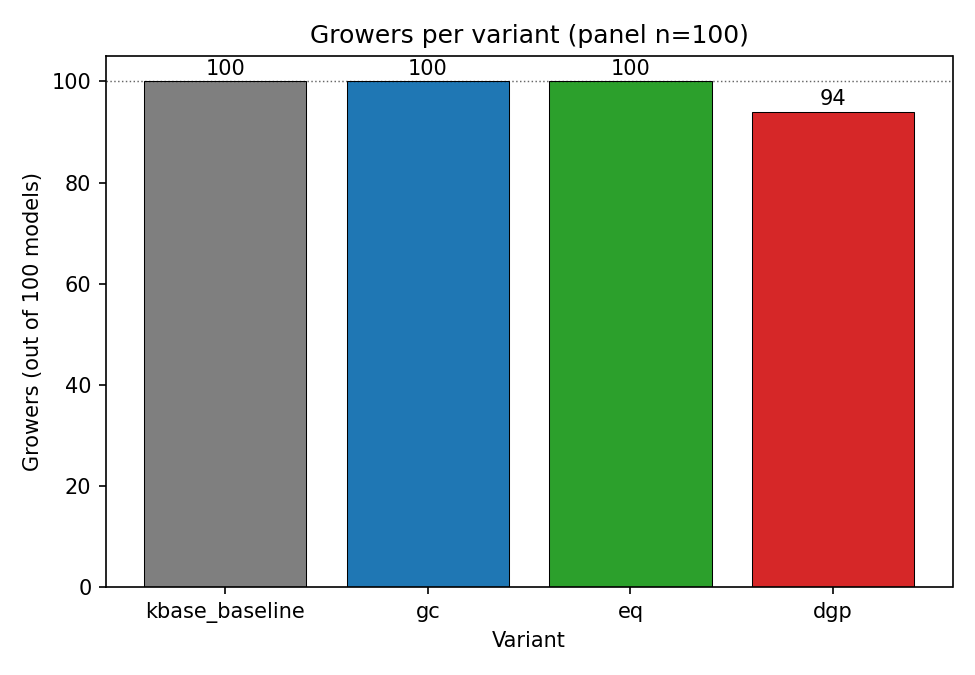

In [11]:
from IPython.display import Image, display
display(Image(filename=str(FIG_GROWER_COUNTS)))

### Figure 2 -- Mean growth flux (growers only)

Mean growth flux per variant, restricted to models that actually grow. Annotated bar values are the means in flux units.

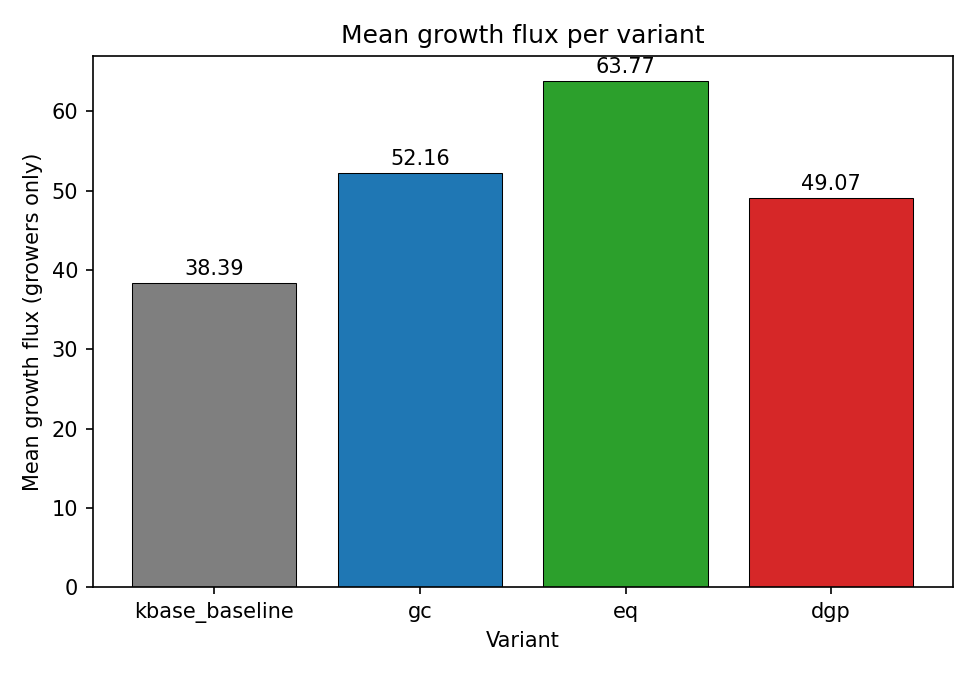

In [12]:
from IPython.display import Image, display
display(Image(filename=str(FIG_MEAN_FLUX)))

### Figure 3 -- Per-model growth flux distribution

Violin + jittered strip plot of growth flux per variant on a log y-axis. Black horizontal line in each violin is the median; a small offset is added to handle zero-flux models on the log scale.

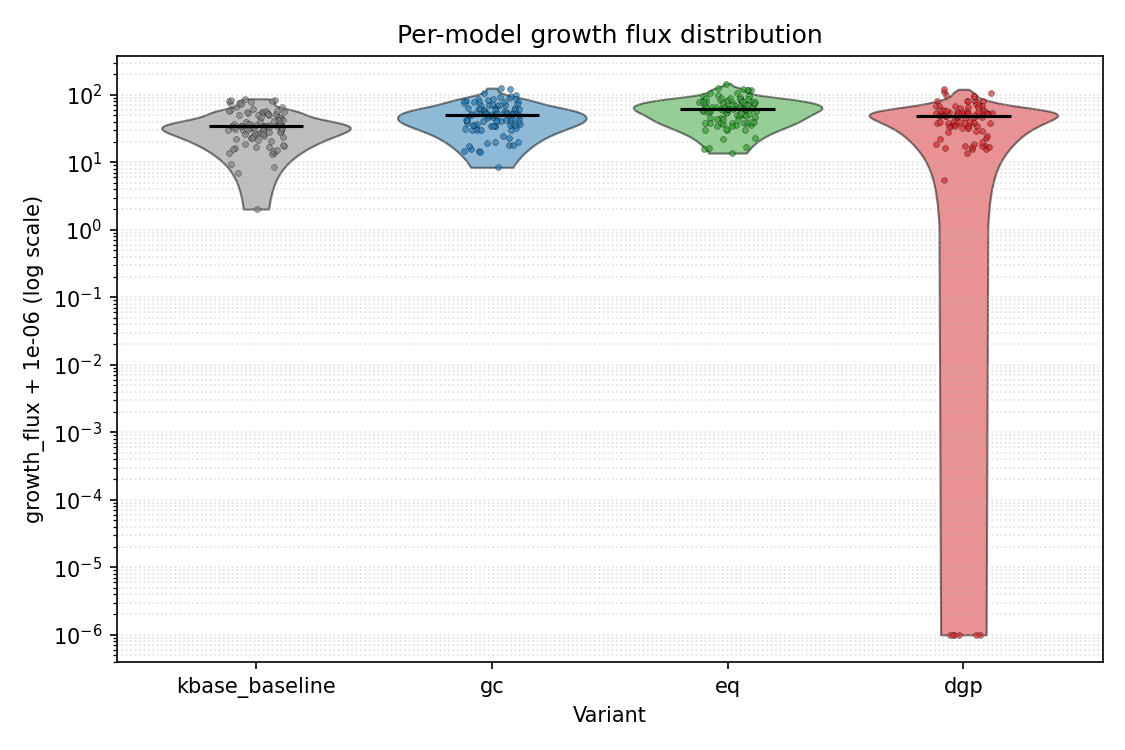

In [13]:
from IPython.display import Image, display
display(Image(filename=str(FIG_FLUX_VIOLIN)))

### Figure 4 -- Per-model heatmap

100-row x 4-column heatmap of growth flux, sorted by KBase baseline flux. Log-scaled viridis colormap; lets you spot model-level winners and losers across variants.

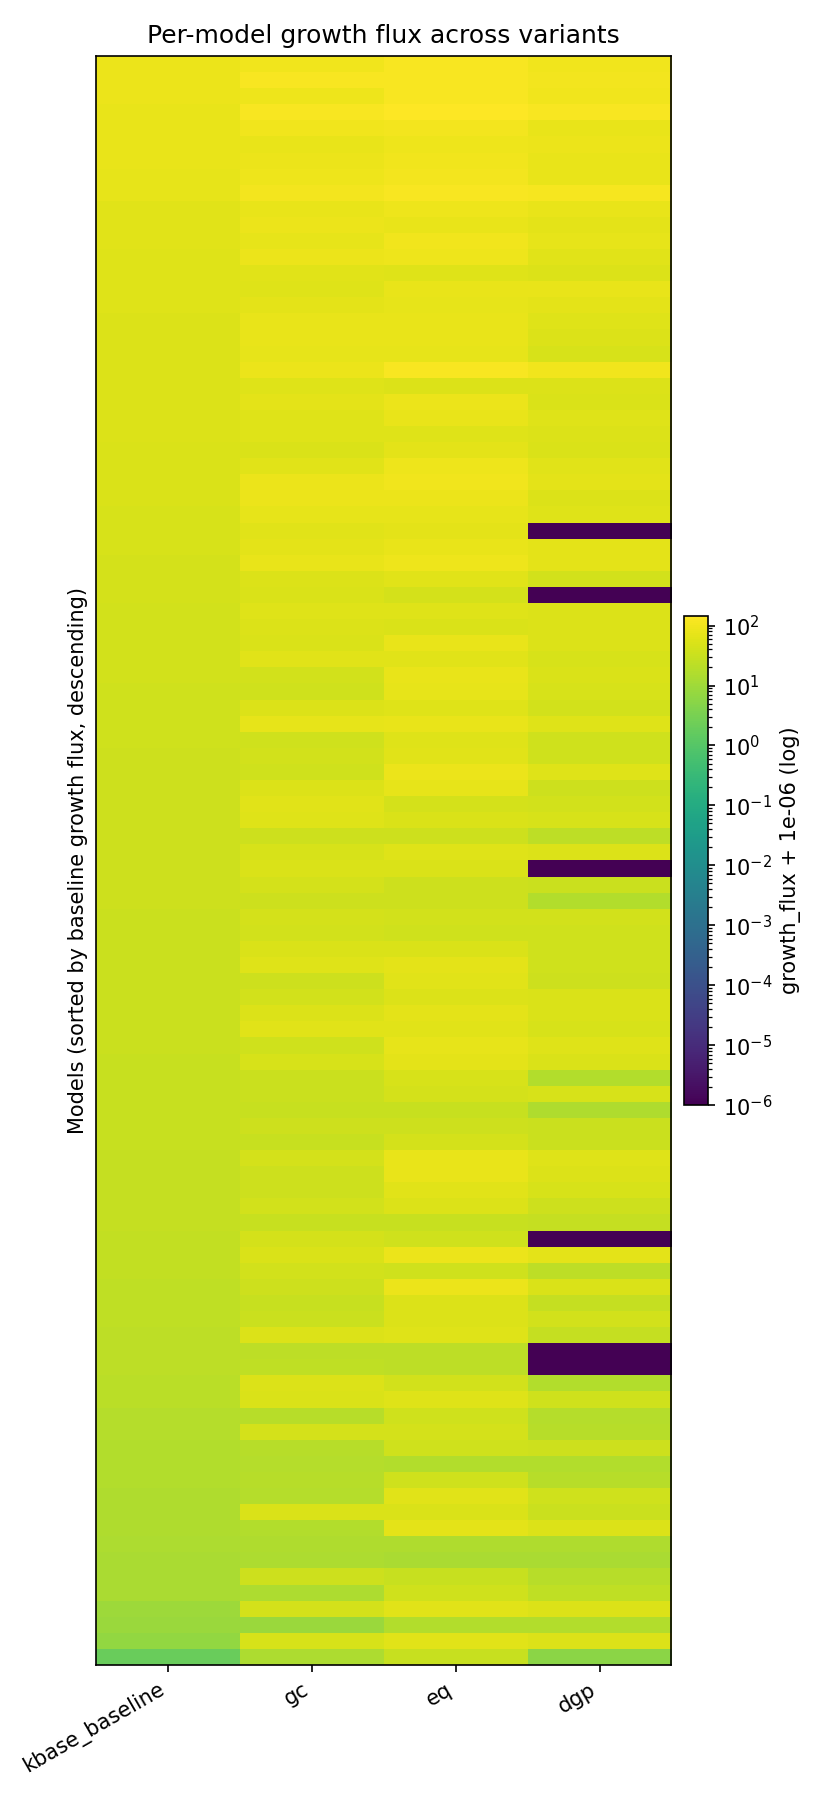

In [14]:
from IPython.display import Image, display
display(Image(filename=str(FIG_PER_MODEL_HEATMAP)))

### Figure 5 -- Per-model coverage by source

1x3 histogram of the per-model fraction of reactions covered by each source's operator map.  Dashed line is the per-source mean.  Reactions that aren't covered fall back to their on-disk KBase bounds.

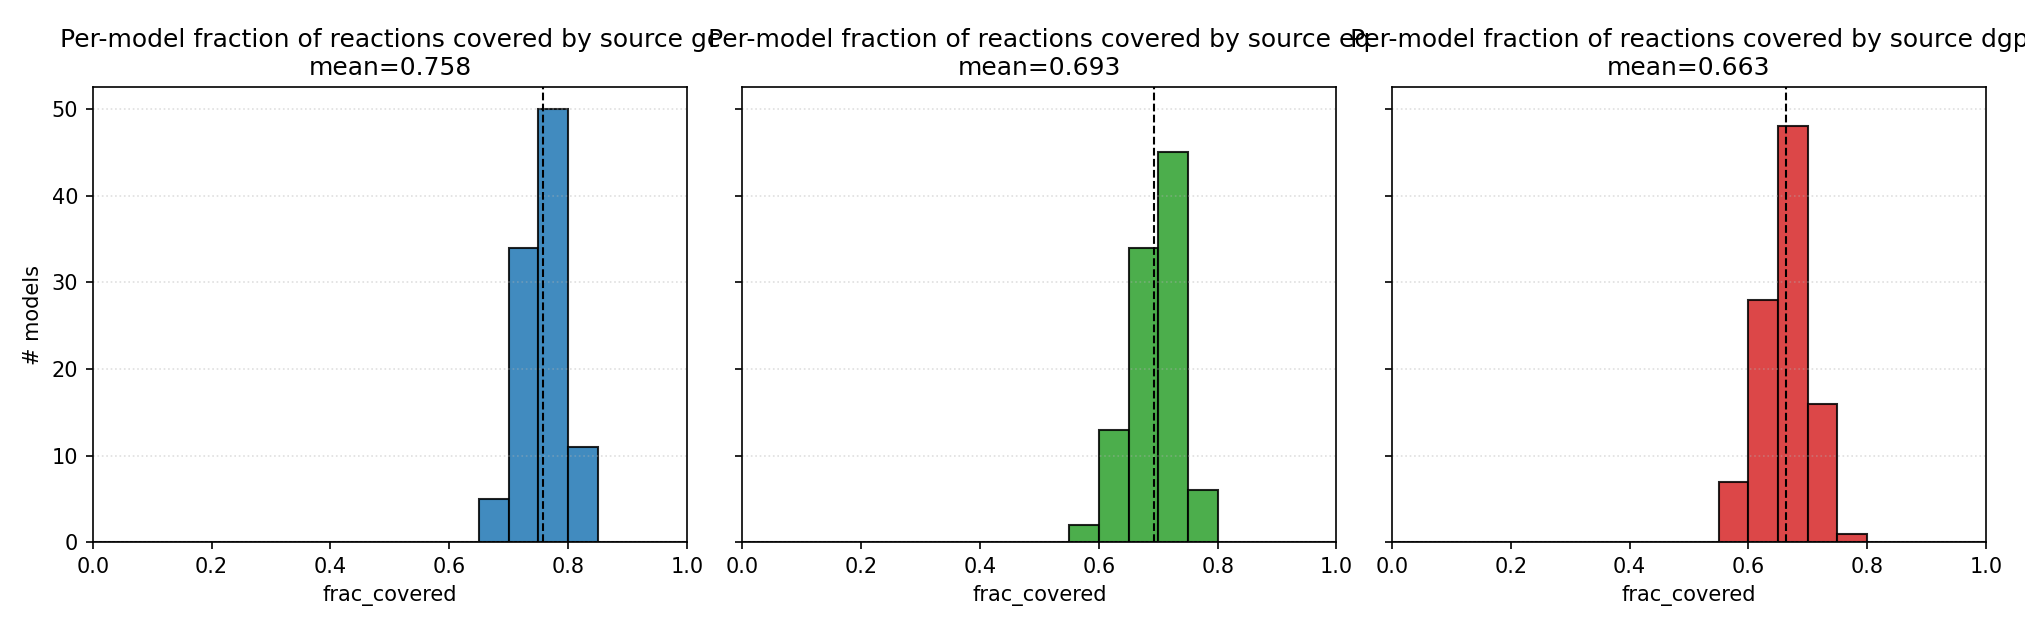

In [15]:
from IPython.display import Image, display
display(Image(filename=str(FIG_COVERAGE_PER_SOURCE)))

### Figure 6 -- Override transitions per source

Stacked bar of every bound-class transition (fwd / rev / reversible) the per-source override would apply, summed across the 100-model panel.  Read from the wide-schema `overrides_<slug>.csv` written above.

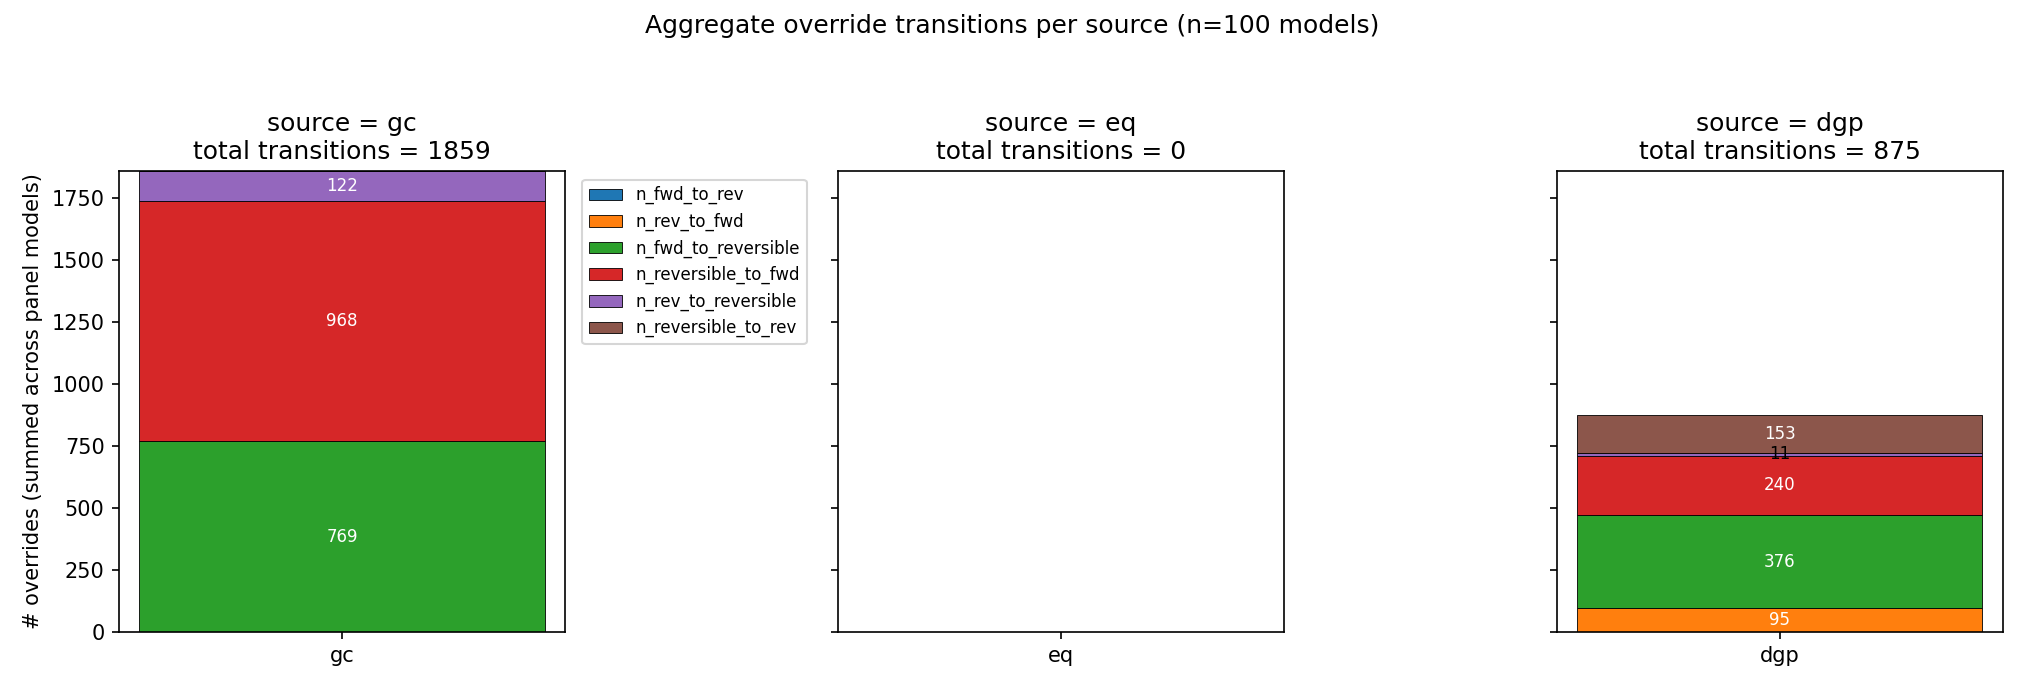

In [16]:
from IPython.display import Image, display
display(Image(filename=str(FIG_OVERRIDE_TRANSITIONS)))

### Figure 7 -- Source flux vs baseline flux (scatter)

1x3 scatter of per-model source flux vs KBase baseline flux.  Green = source higher, red = source lower, gray = equal.  Diagonal is `y = x`.

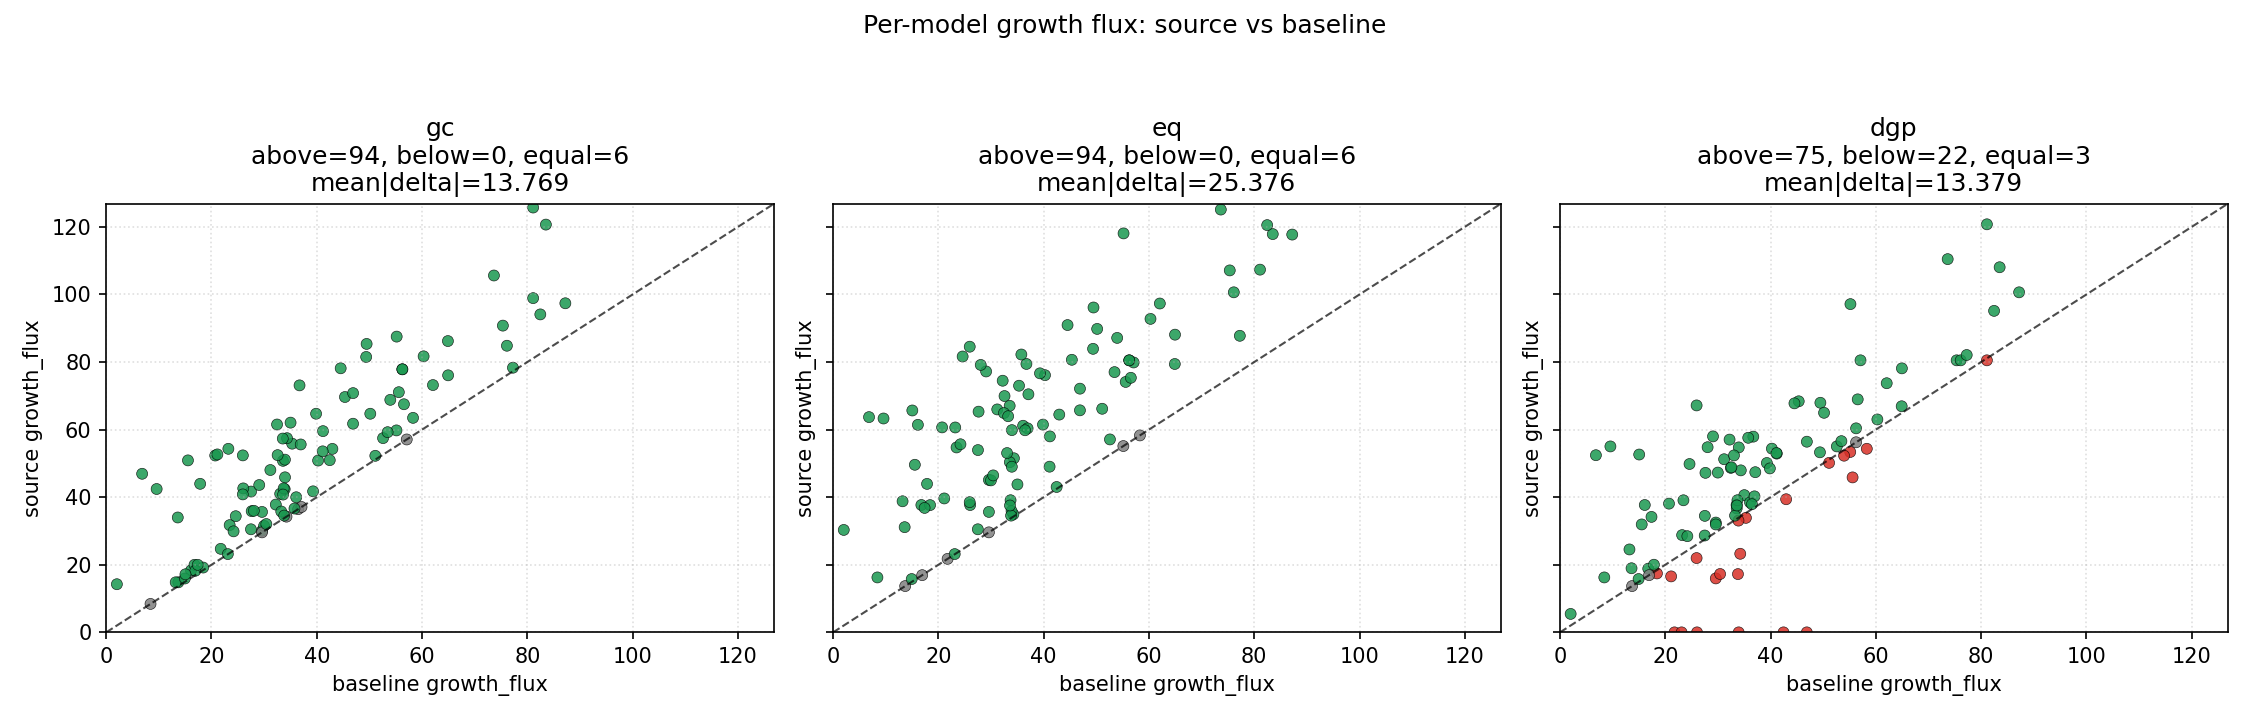

In [17]:
from IPython.display import Image, display
display(Image(filename=str(FIG_FLUX_VS_BASELINE)))

### Figure 8 -- dG distribution per source

1x3 stacked histogram of per-reaction dG estimates per source, colored by the direction operator the source assigns (`<`, `=`, `>`).  Log y-axis.

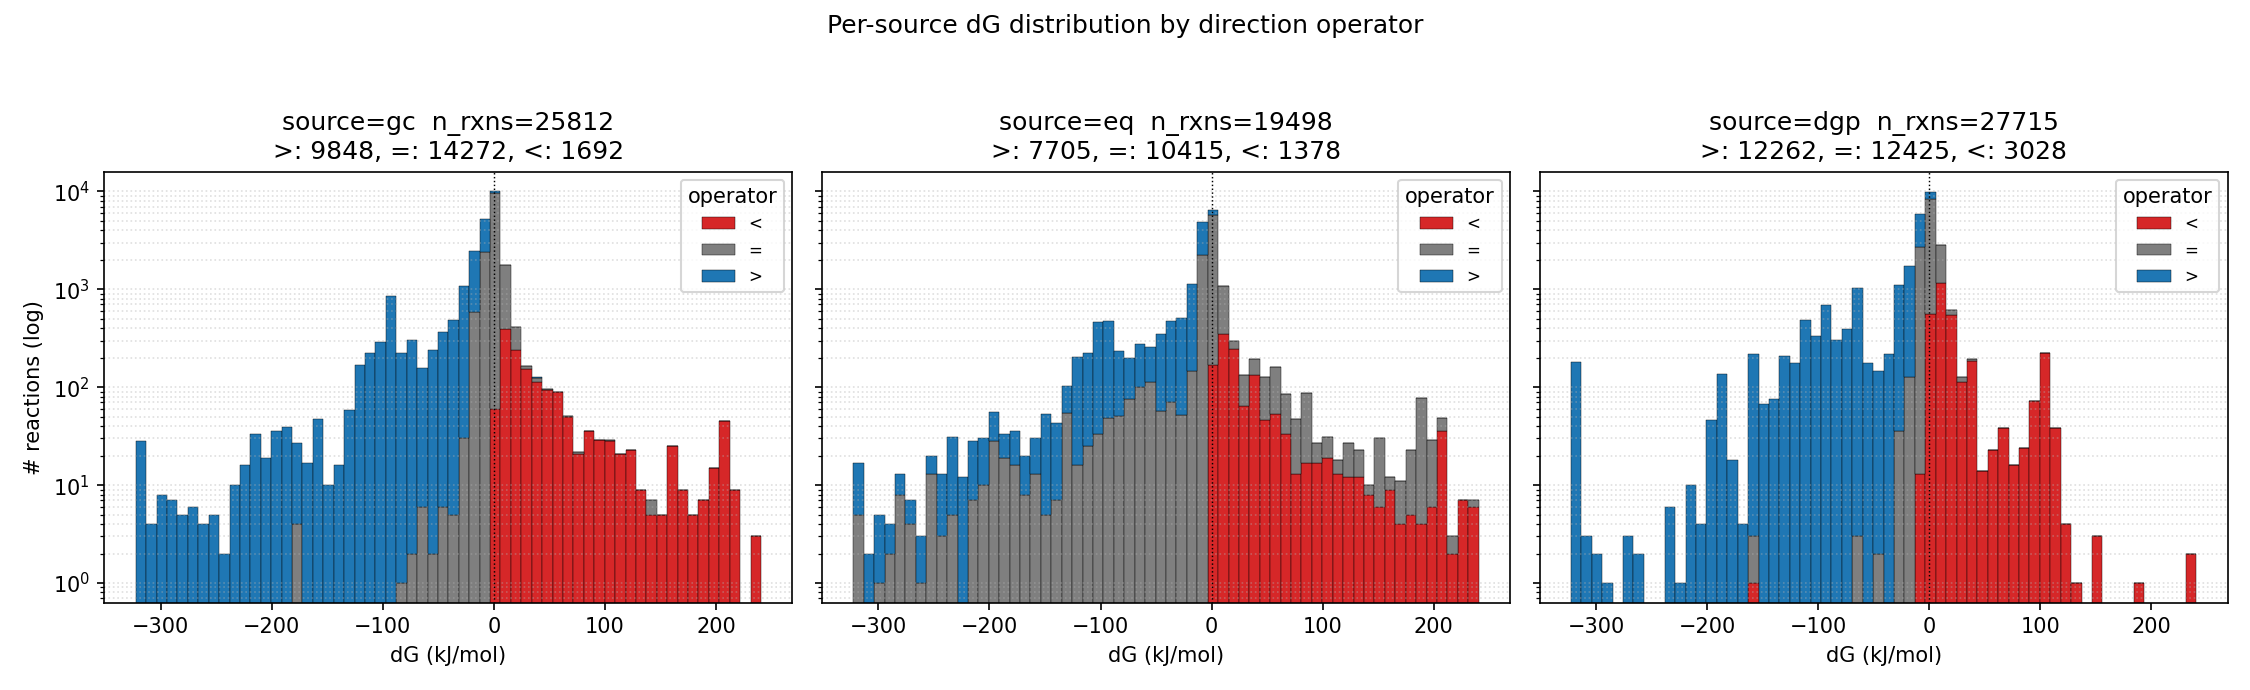

In [18]:
from IPython.display import Image, display
display(Image(filename=str(FIG_DG_DISTRIBUTION)))

## How to re-run

Three equivalent entry points -- all produce the same CSVs under
`results/thermo_sources/` and the same PNGs under
`reports/figures/thermo_sources/`:

1. **This notebook (top-to-bottom):**

   ```bash
   jupyter execute /scratch/ctaylor/core_models_analysis/notebooks/10_ThermoSourceComparison.ipynb
   ```

   Re-running is idempotent: the snapshot cell skips per-source CSVs
   that already exist on disk, and the FBA cells reuse cached results
   from the per-notebook `.kbcache/` directory.

2. **Rebuild the notebook file itself** (e.g. after editing the
   builder script):

   ```bash
   python3 /scratch/ctaylor/core_models_analysis/scripts/build_thermo_source_comparison_notebook.py
   ```

3. **Standalone CLI scripts** (same logic, imported from the same
   helpers this notebook uses):

   ```bash
   # FBA on all 4 variants -> results/thermo_sources/*.csv + .json
   python3 /scratch/ctaylor/core_models_analysis/scripts/run_thermo_source_variants.py

   # Coverage + override transitions -> coverage_<slug>.csv + overrides_<slug>.csv
   python3 /scratch/ctaylor/core_models_analysis/scripts/build_thermo_source_network_tables.py

   # Figures -> reports/figures/thermo_sources/fig_*.png
   python3 /scratch/ctaylor/core_models_analysis/scripts/build_thermo_source_figures.py
   ```

The figure helpers live in
`scripts/thermo_source_figures.py`; the network-table helpers live in
`scripts/direction_pipeline.py` (`source_coverage`,
`override_transitions`, `load_msdb_reversibility_map`).  Both modules
are imported from the notebook AND from the CLI wrappers, so any
logic change made in one place takes effect in the other on the next run.